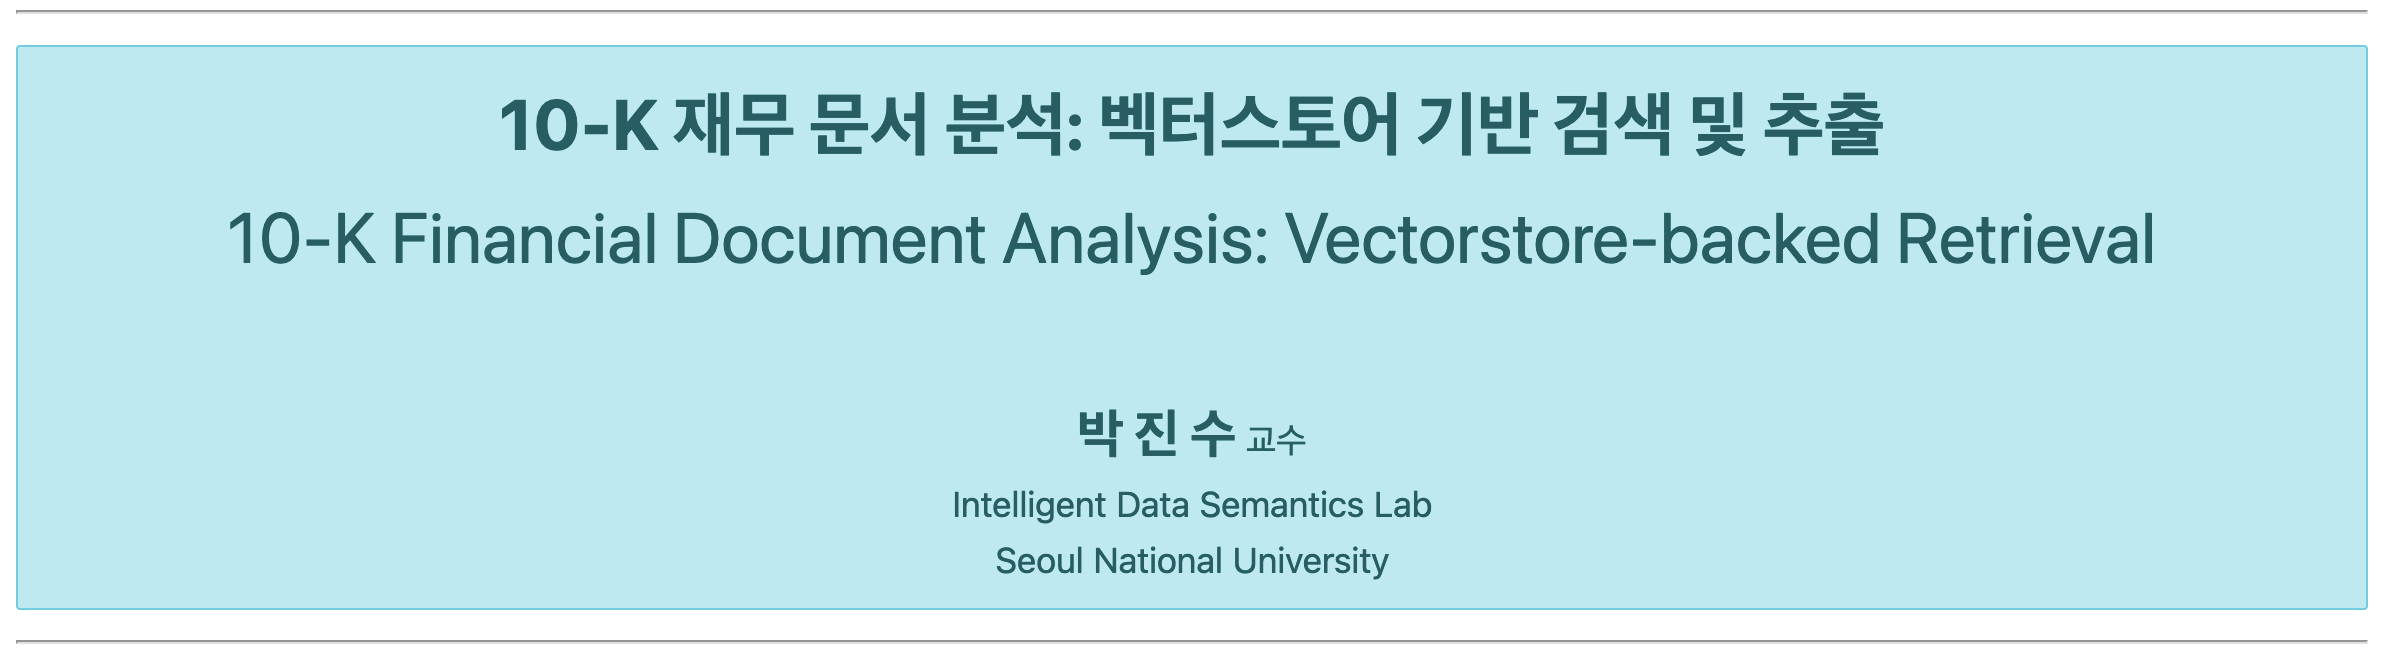

- - -    

- 본 자료는 강의를 위한 목적으로 LangChain이 제공하는 자료에 기반하여 제작했습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

> 파이썬 입문자라면, <http://youtube.com/@myontology>의 **[[학습 프로그램]](https://www.youtube.com/@myontology/courses)** 탭을 활용해 보세요. 기초부터 차근차근 배울 수 있는 파이썬 강의 영상이 준비되어 있어 필요한 내용을 쉽고 빠르게 학습할 수 있습니다.

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span></li><li><span><a href="#인덱싱(indexing)" data-toc-modified-id="인덱싱(indexing)-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>인덱싱(indexing)</a></span><ul class="toc-item"><li><span><a href="#문서-로딩(document-loading)" data-toc-modified-id="문서-로딩(document-loading)-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>문서 로딩(document loading)</a></span></li><li><span><a href="#문서-분할(chunking)" data-toc-modified-id="문서-분할(chunking)-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>문서 분할(chunking)</a></span></li><li><span><a href="#문서-저장:-벡터-저장소(vectorstores)" data-toc-modified-id="문서-저장:-벡터-저장소(vectorstores)-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>문서 저장: 벡터 저장소(vectorstores)</a></span></li></ul></li><li><span><a href="#검색-추출(retrieval)" data-toc-modified-id="검색-추출(retrieval)-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>검색 추출(retrieval)</a></span><ul class="toc-item"><li><span><a href="#Similarity-Search" data-toc-modified-id="Similarity-Search-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Similarity Search</a></span></li><li><span><a href="#Similarity-Search-with-Score" data-toc-modified-id="Similarity-Search-with-Score-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Similarity Search with Score</a></span></li><li><span><a href="#Max-Marginal-Relevance" data-toc-modified-id="Max-Marginal-Relevance-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Max Marginal Relevance</a></span></li><li><span><a href="#[참고-예시]-Similarity-Search-vs.-MMR-Search" data-toc-modified-id="[참고-예시]-Similarity-Search-vs.-MMR-Search-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>[참고 예시] Similarity Search vs. MMR Search</a></span></li></ul></li><li><span><a href="#RAG의-잠재적-문제" data-toc-modified-id="RAG의-잠재적-문제-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>RAG의 잠재적 문제</a></span></li></ul></div>

<span style='font-size: large; font-weight: bold;'>관련 파일 가져오기</span>

In [ ]:
# --- 하위 폴더 'data'가 없으면 새로 만든다.
from pathlib import Path
Path('data').mkdir(exist_ok=True)  # If exist_ok is true, FileExistsError exceptions will be ignored

!gdown 11bBYdCSSVYnOkXn_3du-uSd1ZmVoBwZk -O data/apple-10k-2025.pdf
!gdown 1fF5zyaudfLHQycWHmW_-fNfxIuNy-wrm -O data/google-10k-2025.pdf
!gdown 1qw8SnffR2u_xC20-swGcp4SUBVrPgPTu -O data/uber-10k-2025.pdf
!gdown 1SvW1AD958WbZWn-0XRb32hCWvunq3AcC -O data/lyft-10k-2025.pdf

# 패키지 설치 및 API 설정

In [ ]:
!python -m pip install -qU python-dotenv gdown pypdf pandas seaborn langchain langchain-chroma# YOUR LLM package HERE(e.g., openai anthropic google-genai groq mistralai ollama)
print('--- Installation Completed', '-' * 55, '\n')

In [ ]:
# 방법 1 - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

In [ ]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

# 인덱싱(indexing)

- - -
**인덱싱(indexing)**  
- 데이터 소스에서 데이터를 취득하고 색인화하는 과정
- - -

## 문서 로딩(document loading)

In [1]:
from langchain_community.document_loaders import PyPDFLoader
from pathlib import Path

folder = Path('data')
files = [
    'apple-10k-2025.pdf',   
    'google-10k-2025.pdf', 
    'uber-10k-2025.pdf', 
    'lyft-10k-2025.pdf'  
]  
loaders = [PyPDFLoader(str(folder / file)) for file in files]

pages = [pages_ for loader in loaders for pages_ in loader.load()]  
print(f'{len(files)} documents and total {len(pages)} pages.')  

4 documents and total 449 pages.


In [5]:
pages[0].metadata

{'producer': 'Wdesk Fidelity Content Translations Version 014.006.087',
 'creator': 'Workiva',
 'creationdate': '2025-10-30T14:45:03+00:00',
 'author': 'anonymous',
 'moddate': '2025-10-30T08:52:59-07:00',
 'subject': '10-K 2025, 09.27.2025',
 'title': '_10-K 2025 (As-Filed)',
 'source': '/Users/jinsoopark/Dropbox/_data/projects/python/datasets/texts/10k/apple-10k-2025.pdf',
 'total_pages': 80,
 'page': 0,
 'page_label': '1'}

In [6]:
len(pages[0].page_content)

1700

In [7]:
pages[0].page_content

'UNITED STATES\nSECURITIES AND EXCHANGE COMMISSION\nWashington, D.C. 20549\nFORM 10-K\n(Mark One)\n☒    ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934\nFor the fiscal year ended September\xa027, 2025\nor\n☐    TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934\nFor the transition period from \xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0 to \xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0.\nCommission File Number: 001-36743\nApple Inc.\n(Exact name of Registrant as specified in its charter)\nCalifornia 94-2404110\n(State or other jurisdiction\nof incorporation or organization)\n(I.R.S. Employer Identification No.)\nOne Apple Park Way\nCupertino, California 95014\n(Address of principal executive offices) (Zip Code)\n(408) 996-1010\n(Registrant’s telephone number, including area code)\nSecurities registered pursuant to Section 12(b) of the Act:\nTitle of each class\nTrading \nsymbol(s) Name of each exchange on 

## 문서 분할(chunking)

- - -
문서 분할(chunking) 과정에서는  
- 각 청크의 크기(**chunk_size**)가 너무 크면 응답 생성 시간이 지연되며, 너무 작으면 중요 정보를 포함하지 않아 검색하지 못하고 놓칠 수 있다.
- 각 청크의 내용이 전후 청크의 내용과 겹치는 정도(**chunk_overlap**)가 검색기(retriever) 성능에 영향을 미칠 수 있다.
- - -

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

splitter = 
splits   = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

print(len(splits))  

1854


## 문서 저장: 벡터 저장소(vectorstores)

- - -
**벡터 저장소(vectorstore)**
- 데이터를 벡터 형식으로 저장하고 검색할 수 있는 데이터베이스
- 빠른 인덱싱과 검색
    + 고차원 데이터의 효율적 인덱싱으로 빠른 검색 속도를 제공한다.
    + 대규모 데이터에서 유사 항목을 신속하게 찾을 수 있다.
- 고차원 데이터 처리
    + 복잡한 데이터 구조를 효과적으로 관리할 수 있다.
- 다양한 데이터 형식 지원
    + 텍스트, 이미지, 오디오 등 다양한 형식의 데이터 벡터화가 가능하다.
- - -

- - -
**오픈 소스 임베딩 모델을 사용하는 경우**
- Ollama 서버가 실행 중인지 확인한다.
- 실습에 필요한 임베딩 모델을 본인의 로컬 컴퓨터로 내려받는다.
    + **> ollama pull nomic-embed-text**를 통해 모델 가져오기
- - -

In [9]:
# --- save to disk
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_openai import OpenAIEmbeddings


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 임베딩 모델 둘 중 하나를 선택한다. ('text-embedding-3-large'을 추천)
embeddings  = 
path        = 
vectorstore = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

print(vectorstore._collection.count())  

1854


# 검색 추출(retrieval)

## Similarity Search

- - -
**유사성 검색(similarity search)**
- 질의(query) 벡터와 벡터 저장소에 저장된 벡터의 유사성을 기준으로 검색하는 방식이다.
- - -

In [39]:
# --- similarity search 
question = '2025년 Apple의 순이익은 얼마입니까?'

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

retrieved_docs = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

print(len(retrieved_docs))

4


In [5]:
pages = []
for doc in retrieved_docs:
    print(f'Page: {doc.metadata['page_label']}\n{doc.page_content}')
    print('-' * 55) 
    pages.append(doc.metadata['page_label'])
else:
    print(pages)

Page: 50
2024
Americas Europe
Greater
China Japan
Rest of
Asia Pacific Corporate Total
Net sales $ 167,045 $ 101,328 $ 66,952 $ 25,052 $ 30,658 $ — $ 391,035 
Cost of sales  (89,587)  (55,197)  (37,519)  (11,744)  (16,305)  —  (210,352) 
Research and development  —  —  —  —  —  (31,370)  (31,370) 
Selling and marketing  (9,802)  (4,341)  (2,351)  (854)  (1,291)  —  (18,639) 
General and administrative  —  —  —  —  —  (7,458)  (7,458) 
Operating income/(loss) $ 67,656 $ 41,790 $ 27,082 $ 12,454 $ 13,062 $ (38,828) $ 123,216 
2023
Americas Europe
Greater
China Japan
Rest of
Asia Pacific Corporate Total
Net sales $ 162,560 $ 94,294 $ 72,559 $ 24,257 $ 29,615 $ — $ 383,285 
Cost of sales  (92,394)  (54,101)  (39,787)  (11,542)  (16,313)  —  (214,137) 
Research and development  —  —  —  —  —  (29,915)  (29,915) 
Selling and marketing  (9,658)  (4,095)  (2,444)  (827)  (1,236)  —  (18,260) 
General and administrative  —  —  —  —  —  (6,672)  (6,672) 
Operating income/(loss) $ 60,508 $ 36,098

## Similarity Search with Score

- - -
반환한 거리 점수는 <u>코사인 거리</u>다. 따라서 <u>점수가 낮을수록 좋다</u>.

**코사인 거리(cosine distance)**
- 두 벡터 간의 방향 차이를 측정하는 방법으로 벡터 간의 각도를 이용하여 유사성을 계산한다.
- 값의 범위:
    + **0**: 완전히 동일
    + **2**: 완전히 반대
- 수식 : $\text{cosine distance} = 1 - \text{cosine similarity}$
- [참고] **코사인 유사도(cosine similarity)**: 두 벡터 간의 코사인 각도를 기반으로 유사성을 측정
    + **-1**: 완전히 반대
    + **1**: 완전히 동일

- - -

In [44]:
# --- similarity search with score
question = '2025년 Apple의 순이익은 얼마입니까?'

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

retrieved_docs = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

print(len(retrieved_docs))

4


In [11]:
pages = []
for doc in retrieved_docs:
    print(f'Page: {doc[0].metadata['page_label']}\n{doc[0].page_content}\nScore: {doc[1]}')
    print('-' * 55) 
    pages.append(doc[0].metadata['page_label'])
else:
    print(pages)

Page: 50
2024
Americas Europe
Greater
China Japan
Rest of
Asia Pacific Corporate Total
Net sales $ 167,045 $ 101,328 $ 66,952 $ 25,052 $ 30,658 $ — $ 391,035 
Cost of sales  (89,587)  (55,197)  (37,519)  (11,744)  (16,305)  —  (210,352) 
Research and development  —  —  —  —  —  (31,370)  (31,370) 
Selling and marketing  (9,802)  (4,341)  (2,351)  (854)  (1,291)  —  (18,639) 
General and administrative  —  —  —  —  —  (7,458)  (7,458) 
Operating income/(loss) $ 67,656 $ 41,790 $ 27,082 $ 12,454 $ 13,062 $ (38,828) $ 123,216 
2023
Americas Europe
Greater
China Japan
Rest of
Asia Pacific Corporate Total
Net sales $ 162,560 $ 94,294 $ 72,559 $ 24,257 $ 29,615 $ — $ 383,285 
Cost of sales  (92,394)  (54,101)  (39,787)  (11,542)  (16,313)  —  (214,137) 
Research and development  —  —  —  —  —  (29,915)  (29,915) 
Selling and marketing  (9,658)  (4,095)  (2,444)  (827)  (1,236)  —  (18,260) 
General and administrative  —  —  —  —  —  (6,672)  (6,672) 
Operating income/(loss) $ 60,508 $ 36,098

## Max Marginal Relevance

- - -
**최대 한계 관련성(maximal marginal relevance, MMR)** 검색
- 질의(query) 벡터와 유사한 벡터를 선택하면서 동시에 이미 선택한 문서와 지나치게 유사한 문서에 불이익을 부여(penalizing)하여 유사성과 다양성을 동시에 확보하는 검색 방식이다.
- 즉, 중복을 최소화하면서 관련성을 최대화하는 검색 기법으로 다중 유사한 결과를 피하고 다양한 결과를 제공한다.
- 장점
    + 관련성과 다양성을 동시에 고려하기 때문에 중복을 최소화하면서도 다양한 결과를 제공하여 사용자 경험을 향상시킬 수 있다.
    + 동일한 결과가 반복되지 않아 더 많은 정보를 얻을 수 있다.
- 단점
    + 가중치 값에 따라 관련성과 다양성 간의 균형이 달라지며, 최적의 값을 찾기 어려울 수 있다.
    + 모든 문서 간의 유사도를 계산해야 하므로 계산 비용이 높아질 수 있기 때문에 대규모 데이터셋에서는 실시간 처리에 어려움이 있을 수 있다.
    + 입력 데이터의 품질이 낮으면, 즉 잘못된 또는 노이즈가 많은 데이터가 포함된 경우 MMR의 성능도 저하될 수 있기 때문에 비효율적인 결과가 나올 수 있다.
- - -

In [49]:
# --- MMR search
question = '2025년 Apple의 순이익은 얼마입니까?'

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

retrieved_docs = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

print(len(retrieved_docs))

4


In [15]:
pages = []
for doc in retrieved_docs:
    print(f'Page: {doc.metadata['page_label']}\n{doc.page_content}')
    print('-' * 55) 
    pages.append(doc.metadata['page_label'])
else:
    print(pages)

Page: 50
2024
Americas Europe
Greater
China Japan
Rest of
Asia Pacific Corporate Total
Net sales $ 167,045 $ 101,328 $ 66,952 $ 25,052 $ 30,658 $ — $ 391,035 
Cost of sales  (89,587)  (55,197)  (37,519)  (11,744)  (16,305)  —  (210,352) 
Research and development  —  —  —  —  —  (31,370)  (31,370) 
Selling and marketing  (9,802)  (4,341)  (2,351)  (854)  (1,291)  —  (18,639) 
General and administrative  —  —  —  —  —  (7,458)  (7,458) 
Operating income/(loss) $ 67,656 $ 41,790 $ 27,082 $ 12,454 $ 13,062 $ (38,828) $ 123,216 
2023
Americas Europe
Greater
China Japan
Rest of
Asia Pacific Corporate Total
Net sales $ 162,560 $ 94,294 $ 72,559 $ 24,257 $ 29,615 $ — $ 383,285 
Cost of sales  (92,394)  (54,101)  (39,787)  (11,542)  (16,313)  —  (214,137) 
Research and development  —  —  —  —  —  (29,915)  (29,915) 
Selling and marketing  (9,658)  (4,095)  (2,444)  (827)  (1,236)  —  (18,260) 
General and administrative  —  —  —  —  —  (6,672)  (6,672) 
Operating income/(loss) $ 60,508 $ 36,098

## [참고 예시] Similarity Search vs. MMR Search

In [24]:
texts = [
    '광대버섯(Amanita phalloides)은 크고 위풍당당한 외피성(지상 위) '
    '자실체(담자과체)를 가지고 있다.',
    '큰 자실체를 가진 버섯은 광대버섯(Amanita phalloides)이다. '
    '일부 품종은 순백색이다.',
    '일명 죽음의 모자(Death Cap)라고도 불리는 팔로이드는 알려진 버섯 중 '
    '가장 독성이 강한 버섯 중 하나이다.'
]

In [25]:
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_openai import OpenAIEmbeddings

vs = Chroma.from_texts(
    texts=texts,
    embedding=OpenAIEmbeddings(model='text-embedding-3-small'),
    collection_metadata={'hnsw:space': 'cosine'}  
)

In [26]:
question = '큰 자실체를 가진 순백색 버섯에 대해 알려주세요.'

In [30]:
# --- similarity search
retrieved_docs = vs.similarity_search(query=question, k=2)  
for doc in retrieved_docs:
    print(doc.page_content)

큰 자실체를 가진 버섯은 광대버섯(Amanita phalloides)이다. 일부 품종은 순백색이다.
광대버섯(Amanita phalloides)은 크고 위풍당당한 외피성(지상 위) 자실체(담자과체)를 가지고 있다.


In [31]:
# --- a similarity search with MMR
retrieved_docs = vs.max_marginal_relevance_search(
    query=question,
    k=2,       
    fetch_k=3  
)
for doc in retrieved_docs:
    print(doc.page_content)

큰 자실체를 가진 버섯은 광대버섯(Amanita phalloides)이다. 일부 품종은 순백색이다.
일명 죽음의 모자(Death Cap)라고도 불리는 팔로이드는 알려진 버섯 중 가장 독성이 강한 버섯 중 하나이다.


# RAG의 잠재적 문제

In [13]:
question = '2025년 Apple의 순이익은 얼마입니까?'
retrieved_docs = vectorstore.similarity_search(question)  
for doc in retrieved_docs:
    print(f'{doc.metadata['source'].rpartition('/')[-1]} -> {doc.metadata['page_label']} page')     

apple-10k-2025.pdf -> 50 page
apple-10k-2025.pdf -> 32 page
apple-10k-2025.pdf -> 33 page
apple-10k-2025.pdf -> 39 page


In [14]:
print(retrieved_docs[0].page_content)

2024
Americas Europe
Greater
China Japan
Rest of
Asia Pacific Corporate Total
Net sales $ 167,045 $ 101,328 $ 66,952 $ 25,052 $ 30,658 $ — $ 391,035 
Cost of sales  (89,587)  (55,197)  (37,519)  (11,744)  (16,305)  —  (210,352) 
Research and development  —  —  —  —  —  (31,370)  (31,370) 
Selling and marketing  (9,802)  (4,341)  (2,351)  (854)  (1,291)  —  (18,639) 
General and administrative  —  —  —  —  —  (7,458)  (7,458) 
Operating income/(loss) $ 67,656 $ 41,790 $ 27,082 $ 12,454 $ 13,062 $ (38,828) $ 123,216 
2023
Americas Europe
Greater
China Japan
Rest of
Asia Pacific Corporate Total
Net sales $ 162,560 $ 94,294 $ 72,559 $ 24,257 $ 29,615 $ — $ 383,285 
Cost of sales  (92,394)  (54,101)  (39,787)  (11,542)  (16,313)  —  (214,137) 
Research and development  —  —  —  —  —  (29,915)  (29,915) 
Selling and marketing  (9,658)  (4,095)  (2,444)  (827)  (1,236)  —  (18,260) 
General and administrative  —  —  —  —  —  (6,672)  (6,672) 
Operating income/(loss) $ 60,508 $ 36,098 $ 30,328

In [15]:
question = '2026년 가장 핫한 뉴스가 뭔가요?'
retrieved_docs = vectorstore.similarity_search(question)  
for doc in retrieved_docs:
    print(f'{doc.metadata['source'].rpartition('/')[-1]} -> {doc.metadata['page_label']} page')     

google-10k-2025.pdf -> 18 page
apple-10k-2025.pdf -> 24 page
google-10k-2025.pdf -> 34 page
apple-10k-2025.pdf -> 24 page


In [16]:
print(retrieved_docs[0].page_content)

litigation and new and expected regulations in a range of jurisdictions.
• AI: Laws and regulations focused on the development, use, and provision of AI technologies and other digital 
products and services, which could result in monetary penalties or other regulatory actions. For example, the 
EU AI Act came into force on August 1, 2024, and will generally become fully applicable after a two-year 
transitional period (although certain obligations have already taken effect). The EU AI Act introduces various 
requirements for AI systems and models placed on the market in the EU, including specific transparency, 
safety, and copyright requirements for general purpose AI systems and the models on which those systems 
are based. Various countries, including Brazil, India, Japan, South Korea, Singapore, and Vietnam, have also 
enacted or are considering enacting regulations focused on AI. In the US, an increasing amount of legislative 
and regulatory activity regarding AI is taking place at

In [17]:
question = '세종대왕에 대한 설명을 해주세요.'
retrieved_docs = vectorstore.similarity_search(question)  
for doc in retrieved_docs:
    print(f'{doc.metadata['source'].rpartition('/')[-1]} -> {doc.metadata['page_label']} page')     

google-10k-2025.pdf -> 5 page
lyft-10k-2025.pdf -> 82 page
google-10k-2025.pdf -> 29 page
google-10k-2025.pdf -> 32 page


In [18]:
print(retrieved_docs[0].page_content)

their data, applying privacy technologies like on-device processing, giving people tools to control their experience, or 
advancing anti-malware, anti-phishing, and password security features.
Google
For reporting purposes Google comprises two segments: Google Services and Google Cloud.
Google Services
Serving Our Users
We have always been committed to building helpful products that can improve the lives of millions of people 
worldwide. Our product innovations are what make our services widely used, and our brand one  of the most 
recognized in the world. Google Services' core products and platforms include ads,  Android, Chrome, devices, Gmail, 
Google Drive, Google Gemini, Google Maps, Google Photos, Google Play, Search, and YouTube,  with broad and 
growing adoption by users around the world.
Table of Contents Alphabet Inc.
4.


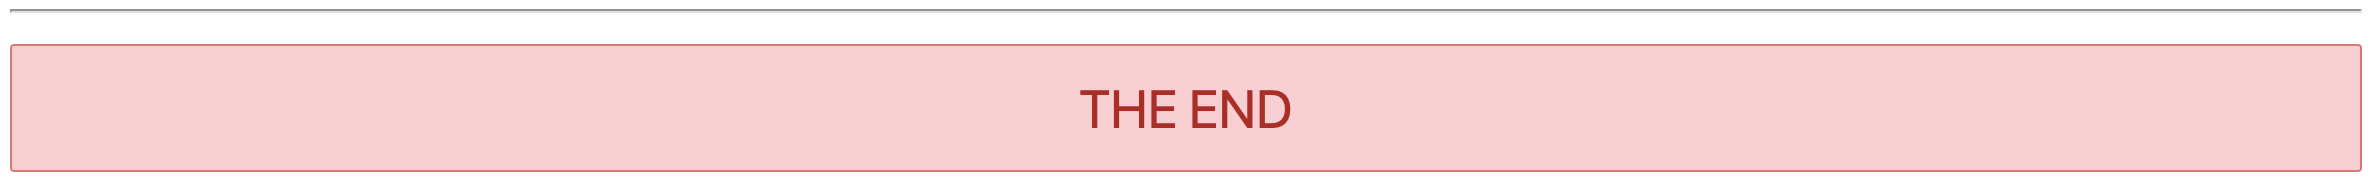